# Visual Tutorial: the Black-Box Adversarial Attack Lineage (FGSM → SQBA)

This notebook walks the **lineage of adversarial attacks** as one continuous story. We start
where the attacker knows everything (**white-box FGSM/PGD**) and climb, one relaxed assumption at
a time, to **SQBA** — a hard-label attack that only ever sees the victim's predicted *label*.

Every rung is presented the same way:
1. a one-line bridge from the **previous** attack to **this** one (what limitation it removes),
2. a **graphic built from the attack itself** — we wrap the victim in a `TracingCtx` that records
   every real query, run the actual function from [`attacks.py`](./attacks.py), and plot what it
   genuinely does (no cartoons), and
3. the attack **executed** on a CIFAR-10 image (airplane vs automobile), with its query count and
   perturbation ratio $\rho = \lVert x_{adv}-x_0\rVert / \lVert x_0\rVert$ (success = $\rho \le 0.25$).

A shared **best-$\rho$-vs-queries** convergence curve runs through every rung, so you can watch
perturbation shrink and query-efficiency improve as we climb toward SQBA.

First, set up the dataset and train/load the victim and surrogate CNNs.

In [1]:
import os
import pickle
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# Set random seed for reproducibility (ensures weights initialize identically across runs)
torch.manual_seed(0)
torch.set_num_threads(max(1, (os.cpu_count() or 2)))
rng = np.random.default_rng(0)
CACHE = os.path.expanduser("~/.cache/blackbox")
CIFAR_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
AIRPLANE, AUTOMOBILE = 0, 1

# --- CIFAR-10 data loading helpers ---
def _read_batch(tar, name):
    d = pickle.load(tar.extractfile(name), encoding="bytes")
    return d[b"data"], np.array(d[b"labels"])

def load_cifar2(c0=AIRPLANE, c1=AUTOMOBILE, n_train=3000, n_test=200):
    npz = os.path.join(CACHE, f"cifar2_{c0}-{c1}_{n_train}_{n_test}.npz")
    if os.path.exists(npz):
        z = np.load(npz)
        return z["Xtr"], z["ytr"], z["Xte"], z["yte"]
    os.makedirs(CACHE, exist_ok=True)
    tarp = os.path.join(CACHE, "cifar-10-python.tar.gz")
    if not os.path.exists(tarp):                  
        urllib.request.urlretrieve(CIFAR_URL, tarp)
    with tarfile.open(tarp) as tar:
        names = tar.getnames()
        trd = [_read_batch(tar, n) for n in sorted(names) if "data_batch" in n]
        ted = [_read_batch(tar, n) for n in names if "test_batch" in n]
    Xtr_all = np.concatenate([d for d, _ in trd]); ytr_all = np.concatenate([l for _, l in trd])
    Xte_all = np.concatenate([d for d, _ in ted]); yte_all = np.concatenate([l for _, l in ted])

    def subset(X, y, n_per):
        outX, outY = [] , []
        for new, c in enumerate((c0, c1)):
            idx = rng.permutation(np.where(y == c)[0])[:n_per]
            outX.append(X[idx]); outY.append(np.full(len(idx), new))
        # Dividing by 255.0 normalizes integer pixel values (0-255) to float range [0.0, 1.0].
        X = np.concatenate(outX).astype(np.float32) / 255.0
        y = np.concatenate(outY).astype(np.int64)
        p = rng.permutation(len(y))
        return X[p], y[p]

    # Subset limits are chosen to allow fast training of models to >=90% test accuracy on CPU.
    Xtr, ytr = subset(Xtr_all, ytr_all, n_train // 2)
    Xte, yte = subset(Xte_all, yte_all, n_test // 2)
    np.savez(npz, Xtr=Xtr, ytr=ytr, Xte=Xte, yte=yte)
    return Xtr, ytr, Xte, yte

Xtr, ytr, Xte, yte = load_cifar2()

# --- CNN Architecture Definitions ---
# MEAN and STD represent channel-wise statistics across CIFAR-10.
# Subtracting mean and dividing by std scales inputs to mean 0, variance 1.
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)

class VictimNet(nn.Module):
    """
    Victim CNN network. Slides 3x3 filters to learn local features. ReLU provides non-linearity.
    Max pool halves the width/height to reduce spatial sizes. Linear projects features to final 2 class scores.
    """
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(3, 32, 3, padding=1)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.c3 = nn.Conv2d(64, 64, 3, padding=1)
        self.fc = nn.Linear(64 * 4 * 4, 2)
    def forward(self, x):
        x = (x - MEAN) / STD
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        x = F.max_pool2d(F.relu(self.c3(x)), 2)
        return self.fc(x.flatten(1))

class SurrogateNet(nn.Module):
    """
    Surrogate CNN network. Deliberately uses a different architecture (5x5 filters)
    to test cross-architecture transferability.
    """
    def __init__(self, width=1.0):
        super().__init__()
        w1, w2 = max(2, int(16 * width)), max(2, int(48 * width))
        self.c1 = nn.Conv2d(3, w1, 5, padding=2)
        self.c2 = nn.Conv2d(w1, w2, 3, padding=1)
        self.fc = nn.Linear(w2 * 8 * 8, 2)
    def forward(self, x):
        x = (x - MEAN) / STD
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        return self.fc(x.flatten(1))

def train_net(net, X, y, epochs=5, bs=64, seed=0, tag=None):
    """
    Standard network training loop. Runs epochs complete loops through training data.
    Opt Adam calculates pixel weight adjustments using cross-entropy classification loss.
    Learning rate 1e-3 is the standard default for Adam.
    """
    if tag:
        ckpt = os.path.join(CACHE, f"net_{tag}.pt")
        if os.path.exists(ckpt):
            net.load_state_dict(torch.load(ckpt)); net.eval(); return net
    torch.manual_seed(seed)
    Xt = torch.tensor(X.reshape(-1, 3, 32, 32), dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    net.train()
    for _ in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), bs):
            idx = perm[i:i + bs]
            opt.zero_grad()
            F.cross_entropy(net(Xt[idx]), yt[idx]).backward()
            opt.step()
    net.eval()
    if tag:
        torch.save(net.state_dict(), os.path.join(CACHE, f"net_{tag}.pt"))
    return net

def accuracy(net, X, y):
    with torch.no_grad():
        pred = net(torch.tensor(X.reshape(-1, 3, 32, 32), dtype=torch.float32)).argmax(1).numpy()
    return float((pred == y).mean())

print("Training CNNs (or loading cached weights)...")
# Epoch limits (12/10) are chosen to train models to high test accuracy (>=94%) without overfitting.
victim = train_net(VictimNet(), Xtr, ytr, epochs=12, seed=0, tag="victim_air_auto")
surr_wb = train_net(VictimNet(), Xtr, ytr, epochs=12, seed=0, tag="victim_air_auto")
surr = train_net(SurrogateNet(), Xtr, ytr, epochs=10, seed=7, tag="surr_strong_air_auto")

print(f"Victim CNN Accuracy: {accuracy(victim, Xte, yte):.3f}")
print(f"Replica Surrogate Accuracy: {accuracy(surr_wb, Xte, yte):.3f}")
print(f"Generic Surrogate Accuracy: {accuracy(surr, Xte, yte):.3f}")

Training CNNs (or loading cached weights)...
Victim CNN Accuracy: 0.945
Replica Surrogate Accuracy: 0.945
Generic Surrogate Accuracy: 0.905


## 1. The Query Interface: `Ctx`

Every attack talks to the victim through one object, [`Ctx`](./attacks.py). It exposes
`predict`/`is_adv` (each costs one victim query and increments the counter) and `sgrad` (a *free*
gradient from a surrogate model we own). Routing everything through `Ctx` is what lets us trace and
visualize any attack later without touching `attacks.py`.

We build the context around a **generic surrogate** and pick the first test image the victim
classifies correctly as our target $x_0$.

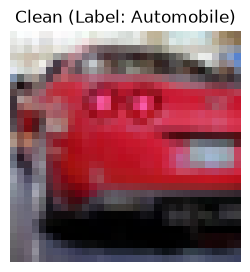

In [2]:
from attacks import Ctx

# Define the victim prediction helper: returns the class index with highest output score.
def make_label(net):
    def label(x):
        with torch.no_grad():
            t = torch.tensor(x.reshape(1, 3, 32, 32), dtype=torch.float32)
            return int(net(t).argmax(1).item())
    return label

victim_label = make_label(victim)

# Define the surrogate gradient builder (calculates gradients w.r.t input pixels).
# Backpropagates cross-entropy loss and normalizes gradient vector to unit length (L2 norm = 1).
# `np.linalg.norm` computes the Euclidean L2 length of the vector: sqrt(sum(g_i^2)).
def make_sgrad(net):
    def sgrad(x, y0):
        t = torch.tensor(x.reshape(1, 3, 32, 32), dtype=torch.float32, requires_grad=True)
        F.cross_entropy(net(t), torch.tensor([y0])).backward()
        g = t.grad.numpy().ravel().astype(np.float64)
        n = np.linalg.norm(g)
        return g / n if n else g
    return sgrad

# Define build_surrogate helper for weakening sweep.
# Minimum pool sample limit of 64 prevents the sub-sampled model from failing training.
def build_surrogate(frac=1.0, width=1.0, label_noise=0.0, epochs=10, seed=7, tag=None):
    idx = rng.choice(len(Xtr), max(64, int(frac * len(Xtr))), replace=False)
    Xs, ys = Xtr[idx].copy(), ytr[idx].copy()
    if label_noise:
        m = rng.random(len(ys)) < label_noise
        ys[m] = rng.integers(0, 2, m.sum())
    return train_net(SurrogateNet(width), Xs, ys, epochs=epochs, seed=seed, tag=tag)

def make_ctx(surrogate_model):
    return Ctx(victim_label, make_sgrad(surrogate_model), Xtr, ytr, rng, lo=0.0, hi=1.0)

# Initialize context with our strong surrogate
ctx = make_ctx(surr)

# Pick the first test image that the victim classifies correctly
x0 = next(Xte[i].astype(np.float64) for i in range(len(Xte)) if victim_label(Xte[i]) == yte[i])
y0 = victim_label(x0)

# Define clean image display helper: transposes from (channels, height, width) to RGB (height, width, channels).
def show_cifar(x, ax, title):
    img = x.reshape(3, 32, 32).transpose(1, 2, 0)
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.set_title(title)
    ax.axis('off')

# Display target clean image
fig, ax = plt.subplots(figsize=(3, 3))
show_cifar(x0, ax, f"Clean (Label: {'Airplane' if y0==0 else 'Automobile'})")
plt.show()

# Define the perturbation ratio metric (rho): Euclidean L2 norm of the change divided by norm of clean image.
rho = lambda adv, x0: np.linalg.norm(adv - x0) / np.linalg.norm(x0)

## 2. Instrumentation Toolkit (`TracingCtx`)

`TracingCtx` subclasses `Ctx` and records every queried point and its label. From that single
record we reconstruct each attack's real behavior — the best-$\rho$ convergence curve, bracket
widths, acceptance rates, probe signs — and re-call real sub-primitives (`mc_normal`, `g_dist`)
at the actual points the attack reaches. **Nothing here changes `attacks.py`**; it is pure
instrumentation used by the graphics below.

In [3]:
from attacks import (Ctx, binary_search, _other_class_sample, loose_start, attack_random,
                     attack_line, attack_boundary, attack_sign_opt, g_dist, attack_hsj,
                     mc_normal, attack_triangle, attack_sqba, attack_sqba_full)

ADV_C, CLEAN_C = "#ef4444", "#10b981"

class TracingCtx(Ctx):
    "Ctx that records every victim query so we can visualize the REAL run."
    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self.trace = []                                  # (query_index, queried_x, label)
    def predict(self, x):
        y = super().predict(x)                           # increments self.q, clips, queries victim
        self.trace.append((self.q, self.clip(x).copy(), int(y)))
        return y
    def best_curve(self, x0, y0):
        "Per-query smallest L2 among adversarial points seen so far."
        qs, ds, best = [], [], np.inf
        for q, x, y in self.trace:
            if y != y0:
                best = min(best, np.linalg.norm(x - x0))
            qs.append(q); ds.append(best)
        return np.array(qs), np.array(ds)

def fresh():
    "A fresh tracing context bound to the generic surrogate (like the global ctx)."
    return TracingCtx(victim_label, make_sgrad(surr), Xtr, ytr, ctx.rng, lo=0.0, hi=1.0)

def accepted_points(tctx, x0, y0):
    "Reconstruct the best-so-far adversarial points (the accepted steps) from the trace."
    acc, best = [], np.inf
    for _, x, l in tctx.trace:
        if l != y0:
            d = np.linalg.norm(x - x0)
            if d < best - 1e-9:
                best = d; acc.append(x)
    return np.array(acc)

def make_basis(u, w):
    "Orthonormal 2-D basis (b1 along u, b2 along the part of w orthogonal to u)."
    b1 = u / (np.linalg.norm(u) or 1.0)
    w2 = w - (w @ b1) * b1; n = np.linalg.norm(w2)
    if n < 1e-12:
        w2 = ctx.rng.standard_normal(u.shape); w2 -= (w2 @ b1) * b1; n = np.linalg.norm(w2)
    return b1, w2 / n

def project2d(points, x0, b1, b2):
    P = np.atleast_2d(points) - x0
    return np.column_stack([P @ b1, P @ b2])

def plot_convergence(tctx, x0, y0, ax, label=None):
    "The shared through-line: best rho found so far vs victim queries."
    qs, ds = tctx.best_curve(x0, y0)
    rhos = np.where(np.isfinite(ds), ds / np.linalg.norm(x0), np.nan)
    ax.plot(qs, rhos, drawstyle="steps-post", lw=2, label=label)
    ax.set_xlabel("victim queries"); ax.set_ylabel("best rho so far"); ax.grid(alpha=.3)
    if label: ax.legend(fontsize=8)

def plot_query_scatter(tctx, x0, y0, b1, b2, ax, title=""):
    pts = np.array([x for _, x, _ in tctx.trace]); labs = np.array([y for _, _, y in tctx.trace])
    P = project2d(pts, x0, b1, b2); adv = labs != y0
    ax.scatter(P[~adv, 0], P[~adv, 1], s=12, c=CLEAN_C, alpha=.45, label="clean (y0)")
    ax.scatter(P[adv, 0], P[adv, 1], s=12, c=ADV_C, alpha=.45, label="adversarial")
    ax.scatter(0, 0, marker="*", s=220, c="black", zorder=5, label="x0")
    ax.set_title(title, fontsize=9); ax.legend(fontsize=8); ax.set_aspect("equal", "datalim")

def plot_alignment(ax, aligns, signs, xlabel, title):
    "Probe alignment with a reference direction vs its real query sign (robust to high dim)."
    jit = ctx.rng.uniform(-0.18, 0.18, len(signs))
    ax.scatter(aligns, np.asarray(signs) + jit, s=45,
               c=[ADV_C if s > 0 else CLEAN_C for s in signs])
    ax.axvline(0, ls="--", color="grey"); ax.set_yticks([-1, 1])
    ax.set_yticklabels(["clean (-1)", "adv (+1)"]); ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=9); ax.grid(alpha=.3)

def plot_acceptance(ax, labs_list, names, y0, win=30):
    "Running acceptance rate of a boundary walk (its distinctive adaptive-step behavior)."
    for labs, name in zip(labs_list, names):
        flags = np.array([1.0 if l != y0 else 0.0 for l in labs])
        if len(flags) >= win:
            ax.plot(np.convolve(flags, np.ones(win) / win, mode="valid"), lw=2, label=name)
    ax.axhspan(0.2, 0.5, color=CLEAN_C, alpha=.12)
    ax.set_xlabel("walk step"); ax.set_ylabel("acceptance rate (%d-step)" % win)
    ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(alpha=.3)

print("toolkit ready: TracingCtx + fresh() + plot helpers")

toolkit ready: TracingCtx + fresh() + plot helpers


## 3. White-Box: FGSM & PGD  *(the attacker knows everything)*

The strongest assumption: the attacker owns a **replica** of the victim (same architecture and
weights) and can read its gradients. **FGSM** takes one gradient-sign step; **PGD** iterates many
small clipped steps inside an $\epsilon$-ball.

**Graphic (from the real attack):** we call `pgd_on_surr` for increasing step counts and plot the
surrogate loss climbing and the perturbation's $L_\infty$ saturating at $\epsilon$ — then the raw
PGD perturbation. These attacks never query the victim (0 queries); they only *transfer*.

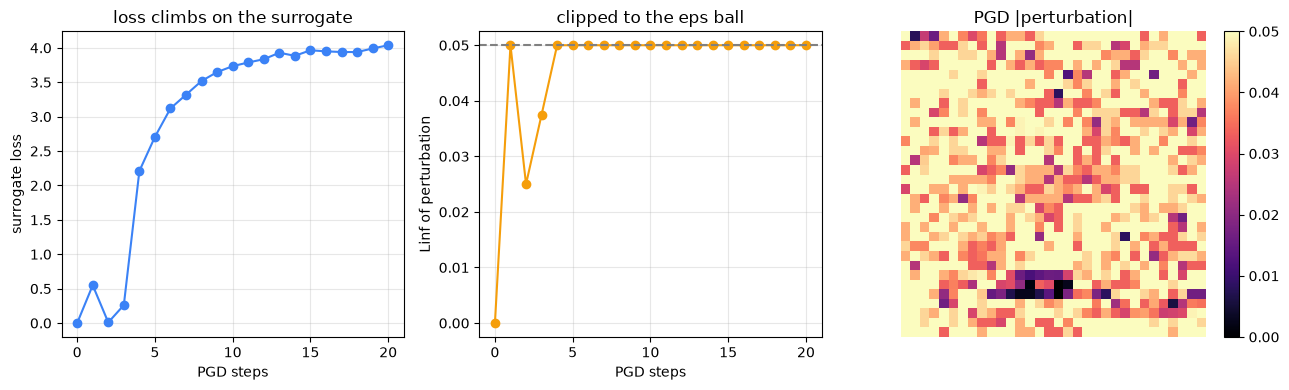

FGSM  rho=0.108  win=False
PGD   rho=0.100  win=True


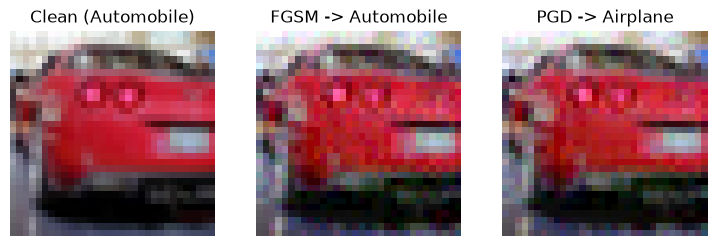

In [4]:
def pgd_on_surr(x0, y0, sgrad, eps, steps):
    "Projected Gradient Descent on a surrogate: sign steps, clipped to the eps-ball and [0,1]."
    x, alpha = x0.copy(), (eps / 4 if steps > 1 else eps)
    for _ in range(steps):
        x = x + alpha * np.sign(sgrad(x, y0))
        x = np.clip(np.clip(x, x0 - eps, x0 + eps), 0, 1)
    return x

def attack_fgsm(x0, y0, sgrad, eps=0.05): return pgd_on_surr(x0, y0, sgrad, eps, 1)
def attack_pgd(x0, y0, sgrad, eps=0.05):  return pgd_on_surr(x0, y0, sgrad, eps, 20)
def attack_transfer(ctx, x0, y0, sgrad):
    "Grow eps on the surrogate until the crafted image flips the victim's label."
    for eps in np.linspace(0.01, 0.25, 16):
        x = pgd_on_surr(x0, y0, sgrad, eps, 15)
        if ctx.is_adv(x, y0):
            return x
    return x

wb_grad_fn = make_sgrad(surr_wb)            # replica surrogate = full white-box access

# --- Intuition from the real attack: PGD climbs surrogate loss, clipped to the eps ball ---
def _surr_loss(x):
    with torch.no_grad():
        return float(F.cross_entropy(surr_wb(torch.tensor(x.reshape(1, 3, 32, 32),
                     dtype=torch.float32)), torch.tensor([y0])))
ks = list(range(0, 21))
paths = [x0 if k == 0 else pgd_on_surr(x0, y0, wb_grad_fn, 0.05, k) for k in ks]
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(ks, [_surr_loss(p) for p in paths], "o-", color="#3b82f6")
ax[0].set_xlabel("PGD steps"); ax[0].set_ylabel("surrogate loss")
ax[0].set_title("loss climbs on the surrogate"); ax[0].grid(alpha=.3)
ax[1].plot(ks, [np.abs(p - x0).max() for p in paths], "o-", color="#f59e0b")
ax[1].axhline(0.05, ls="--", color="grey"); ax[1].set_xlabel("PGD steps")
ax[1].set_ylabel("Linf of perturbation"); ax[1].set_title("clipped to the eps ball"); ax[1].grid(alpha=.3)
xp = attack_pgd(x0, y0, wb_grad_fn)
im = ax[2].imshow(np.abs((xp - x0).reshape(3, 32, 32)).mean(0), cmap="magma")
ax[2].set_title("PGD |perturbation|"); ax[2].axis("off"); fig.colorbar(im, ax=ax[2], fraction=.046)
plt.tight_layout(); plt.show()

# --- Execute on the victim ---
x_fgsm = attack_fgsm(x0, y0, wb_grad_fn); x_pgd = attack_pgd(x0, y0, wb_grad_fn)
print("FGSM  rho=%.3f  win=%s" % (rho(x_fgsm, x0), rho(x_fgsm, x0) <= 0.25 and ctx.fooled(x_fgsm, y0)))
print("PGD   rho=%.3f  win=%s" % (rho(x_pgd, x0), rho(x_pgd, x0) <= 0.25 and ctx.fooled(x_pgd, y0)))
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_cifar(x0, axes[0], "Clean (%s)" % ("Airplane" if y0 == 0 else "Automobile"))
show_cifar(x_fgsm, axes[1], "FGSM -> %s" % ("Airplane" if victim_label(x_fgsm) == 0 else "Automobile"))
show_cifar(x_pgd, axes[2], "PGD -> %s" % ("Airplane" if victim_label(x_pgd) == 0 else "Automobile"))
plt.show()

## 4. Transfer  *(drop the replica — keep a generic surrogate)*

FGSM/PGD assumed a perfect replica. **Transfer** weakens that: the attacker only has a *generic*
surrogate (different architecture) and ~0 victim queries. It crafts PGD images on the generic
surrogate, growing the budget $\epsilon$ until one *transfers* and flips the victim.

**Graphic (from the real attack):** we replay the real $\epsilon$-sweep and mark the smallest
budget at which the victim's label actually flips.

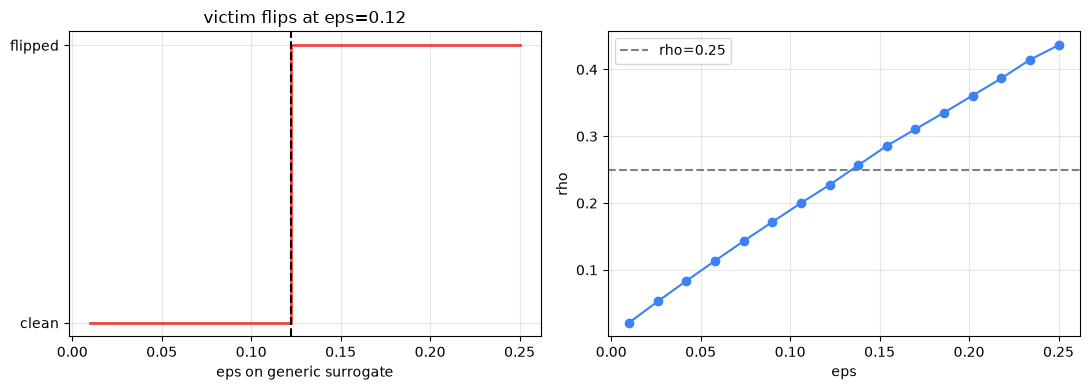

Transfer  rho=0.227  queries=8  win=True


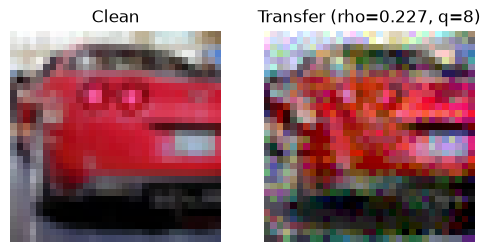

In [5]:
gen_grad = make_sgrad(surr)                 # generic surrogate (different architecture)
tctx = fresh(); epss = np.linspace(0.01, 0.25, 16); flip, rhov = [], []
for e in epss:
    xe = pgd_on_surr(x0, y0, gen_grad, e, 15)
    flip.append(1 if tctx.is_adv(xe, y0) else 0); rhov.append(rho(xe, x0))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].step(epss, flip, where="post", color=ADV_C, lw=2)
first = next((epss[i] for i, f in enumerate(flip) if f), None)
if first is not None:
    ax[0].axvline(first, ls="--", color="black"); ax[0].set_title("victim flips at eps=%.2f" % first)
ax[0].set_xlabel("eps on generic surrogate"); ax[0].set_yticks([0, 1])
ax[0].set_yticklabels(["clean", "flipped"]); ax[0].grid(alpha=.3)
ax[1].plot(epss, rhov, "o-", color="#3b82f6"); ax[1].axhline(0.25, ls="--", color="grey", label="rho=0.25")
ax[1].set_xlabel("eps"); ax[1].set_ylabel("rho"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

ctx.q = 0; x_trans = attack_transfer(ctx, x0, y0, ctx.sgrad); qn = ctx.q
print("Transfer  rho=%.3f  queries=%d  win=%s" % (rho(x_trans, x0), qn, rho(x_trans, x0) <= 0.25 and ctx.fooled(x_trans, y0)))
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(x_trans, axes[1], "Transfer (rho=%.3f, q=%d)" % (rho(x_trans, x0), qn))
plt.show()

## 5. Hard-Label from here on — the `binary_search` primitive

Now the assumption tightens to the hardest case: the victim returns **only its top-1 label**, no
gradients, no scores. The output is a step function, so we can't differentiate it. Every hard-label
attack below extracts a real number from that single bit using one shared primitive: **bisect the
line between an adversarial point and $x_0$** to land exactly on the decision boundary.

**Graphic (from the real primitive):** we trace `binary_search` and watch the bracket width halve
each step while the queried midpoints converge onto the boundary.

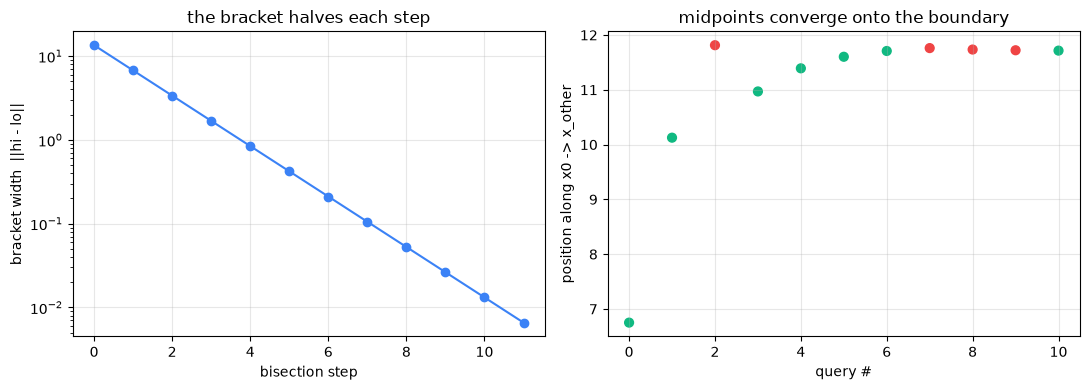

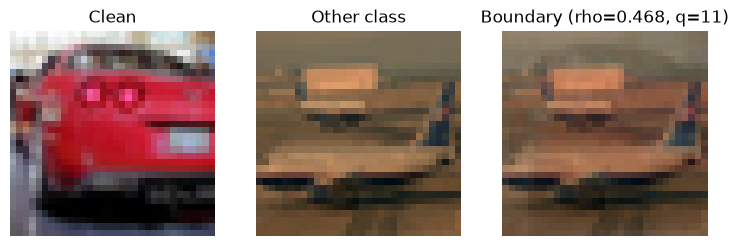

In [6]:
tctx = fresh()
x_other = _other_class_sample(tctx, x0, y0, False)
adv = binary_search(tctx, x_other, x0, y0); qn = tctx.q
dirn = (x_other - x0) / np.linalg.norm(x_other - x0)
lo, hi, widths, tpos, tcol = x0.copy(), x_other.copy(), [np.linalg.norm(x_other - x0)], [], []
for _, m, lab in tctx.trace:
    hi, lo = (m, lo) if lab != y0 else (hi, m)
    widths.append(np.linalg.norm(hi - lo)); tpos.append((m - x0) @ dirn)
    tcol.append(ADV_C if lab != y0 else CLEAN_C)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(range(len(widths)), widths, "o-", color="#3b82f6")
ax[0].set_xlabel("bisection step"); ax[0].set_ylabel("bracket width  ||hi - lo||")
ax[0].set_title("the bracket halves each step"); ax[0].grid(alpha=.3)
ax[1].scatter(range(len(tpos)), tpos, c=tcol, s=40)
ax[1].set_xlabel("query #"); ax[1].set_ylabel("position along x0 -> x_other")
ax[1].set_title("midpoints converge onto the boundary"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(x_other, axes[1], "Other class")
show_cifar(adv, axes[2], "Boundary (rho=%.3f, q=%d)" % (rho(adv, x0), qn)); plt.show()

## 6. Scaffolds: `random` & `line`  *(how to get a first foothold)*

Optimization attacks need a starting adversarial point. Two scaffolds provide one: **random** throws
blind Gaussian noise (hopeless in 3072 dimensions), while **line** walks straight at a different-class
image and binary-searches back. The "loose" variant (`loose_start`) projects the *farthest*
other-class image to the boundary — a guaranteed, deliberately far start the next attacks improve on.

**Graphic (from the real attacks):** a 2-D projection of every real queried point — random scatters
a blind cloud that rarely flips, while line collapses onto a single directed ray (because it *is* a line).

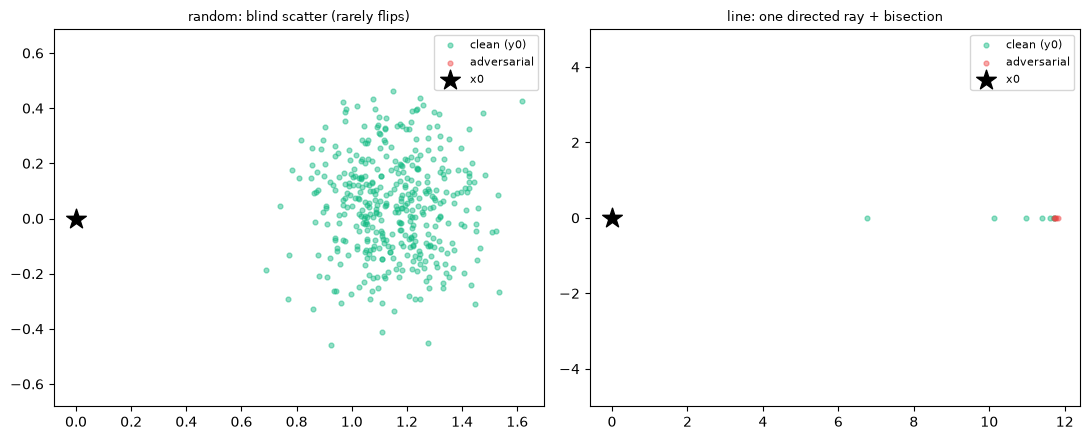

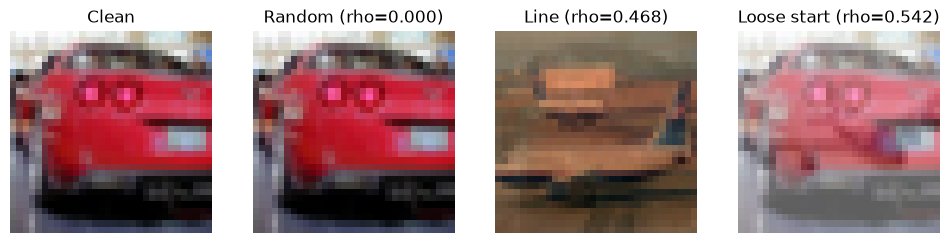

In [7]:
tr = fresh(); x_rand = attack_random(tr, x0, y0, N=400, scale=0.2)
tl = fresh(); x_line = attack_line(tl, x0, y0)
lc = fresh(); loose = loose_start(lc, x0, y0)        # the loose start reused conceptually below
xo = _other_class_sample(tl, x0, y0, False)
b1, b2 = make_basis(xo - x0, ctx.rng.standard_normal(x0.shape))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
plot_query_scatter(tr, x0, y0, b1, b2, ax[0], "random: blind scatter (rarely flips)")
plot_query_scatter(tl, x0, y0, b1, b2, ax[1], "line: one directed ray + bisection")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(x_rand, axes[1], "Random (rho=%.3f)" % rho(x_rand, x0))
show_cifar(x_line, axes[2], "Line (rho=%.3f)" % rho(x_line, x0))
show_cifar(loose, axes[3], "Loose start (rho=%.3f)" % rho(loose, x0)); plt.show()

## 7. Boundary Attack (2018)  *(walk the boundary, no surrogate)*

The line scaffold lands *on* the boundary but far from $x_0$. **Boundary Attack** improves it with a
random walk that *stays* on the boundary: take a small step orthogonal to the radius (constant
distance), then nudge slightly toward $x_0$; keep it only if it remains adversarial. Step sizes adapt
to hold the acceptance rate in a healthy band.

**Graphic (from the real attack):** the running acceptance rate (with the 20–50% target band) shows
the adaptive control, and the convergence curve shows $\rho$ creeping down.

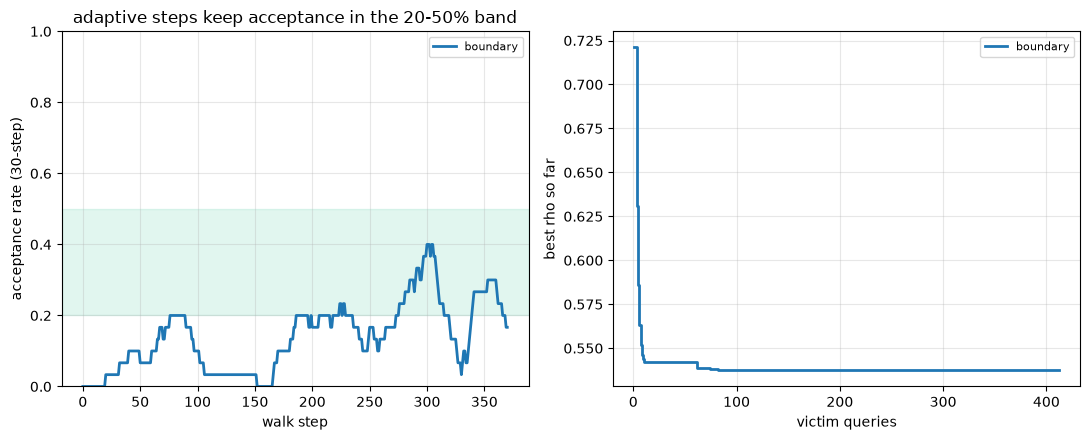

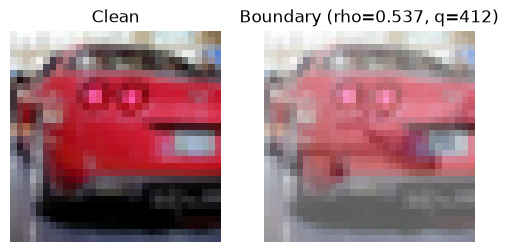

In [8]:
tctx = fresh(); loose = loose_start(tctx, x0, y0); split = len(tctx.trace)
adv = attack_boundary(tctx, x0, y0, loose, steps=400); qn = tctx.q
walk = [l for _, _, l in tctx.trace[split:]]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
plot_acceptance(ax[0], [walk], ["boundary"], y0)
ax[0].set_title("adaptive steps keep acceptance in the 20-50% band")
plot_convergence(tctx, x0, y0, ax[1], "boundary")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(adv, axes[1], "Boundary (rho=%.3f, q=%d)" % (rho(adv, x0), qn))
plt.show()

## 8. OPT → Sign-OPT (2019–2020)  *(optimize a direction, cheaply)*

Boundary Attack wanders. The **OPT** family instead treats the boundary distance along a direction
$\theta$ as a function $g(\theta)$ and does gradient descent on it. OPT measures $g$ with a full
binary search per probe (expensive). **Sign-OPT** replaces each measurement with a single query —
just the **sign** of the change — slashing the per-gradient cost.

**Graphic (from the real attack):** we measure the real per-probe query cost of an OPT-style distance
estimate (`g_dist`) and contrast OPT's gradient budget with Sign-OPT's.

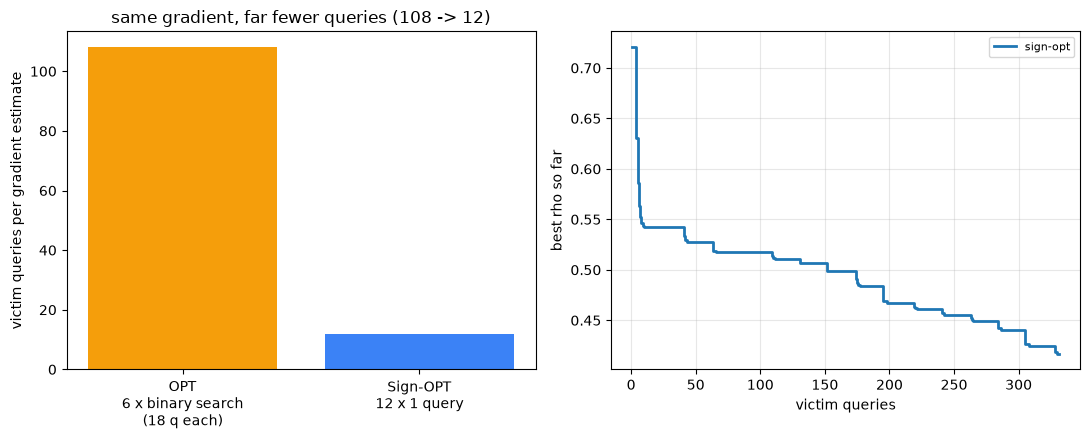

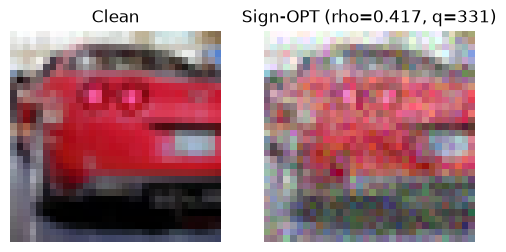

In [9]:
tctx = fresh(); loose = loose_start(tctx, x0, y0)
adv = attack_sign_opt(tctx, x0, y0, loose); qn = tctx.q
probe = fresh(); theta = (loose - x0) / np.linalg.norm(loose - x0)
base = probe.q; g_dist(probe, x0, y0, theta); per_opt = probe.q - base   # queries OPT spends per probe
opt_total, sign_total = 6 * per_opt, 12                                  # attack_opt q=6 vs sign-opt q=12
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].bar(["OPT\n6 x binary search\n(%d q each)" % per_opt, "Sign-OPT\n12 x 1 query"],
          [opt_total, sign_total], color=["#f59e0b", "#3b82f6"])
ax[0].set_ylabel("victim queries per gradient estimate")
ax[0].set_title("same gradient, far fewer queries (%d -> %d)" % (opt_total, sign_total))
plot_convergence(tctx, x0, y0, ax[1], "sign-opt")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(adv, axes[1], "Sign-OPT (rho=%.3f, q=%d)" % (rho(adv, x0), qn))
plt.show()

## 9. HopSkipJump (2020)  *(estimate the boundary normal directly)*

Sign-OPT optimizes one direction at a time. **HopSkipJump** goes after the **boundary normal** — the
single fastest label-changing direction — by Monte-Carlo sampling. It scatters random probes at the
boundary point, labels each $+1$/$-1$ by a query, and *averages* them: the mean points along the normal.

**Graphic (from the real attack):** at the real boundary point we replay the probes and plot each one's
alignment with the averaged normal against its real sign — the two classes separate cleanly, which is
exactly why the average recovers the normal.

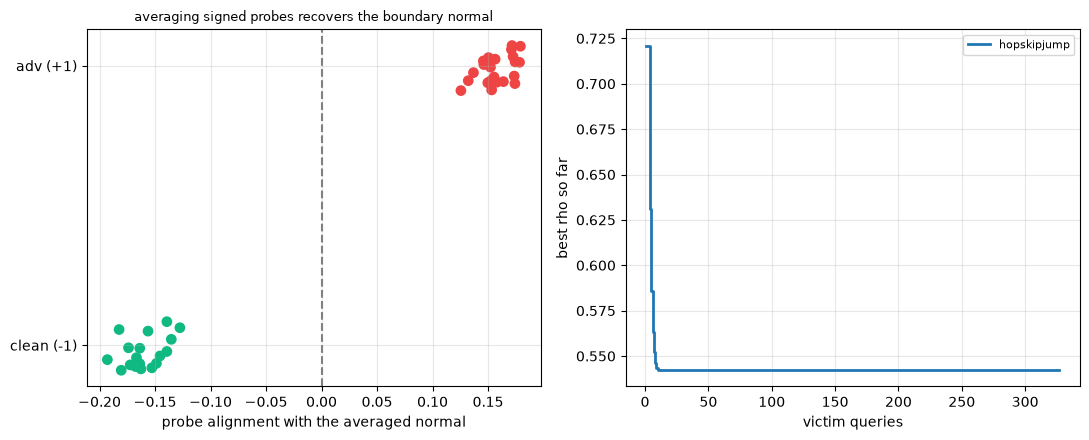

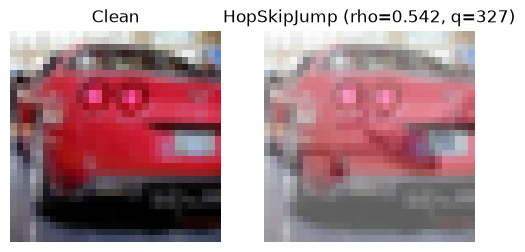

In [10]:
tctx = fresh(); loose = loose_start(tctx, x0, y0)
adv = attack_hsj(tctx, x0, y0, loose); qn = tctx.q
delta = 0.01 * np.linalg.norm(adv - x0); probe = fresh()
U = ctx.rng.standard_normal((40, x0.size)); U /= np.linalg.norm(U, axis=1, keepdims=True)
signs = np.array([1.0 if probe.is_adv(adv + delta * u, y0) else -1.0 for u in U])
normal = (signs[:, None] * U).mean(0); normal /= np.linalg.norm(normal)   # the HSJ estimate
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
plot_alignment(ax[0], U @ normal, signs, "probe alignment with the averaged normal",
               "averaging signed probes recovers the boundary normal")
plot_convergence(tctx, x0, y0, ax[1], "hopskipjump")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(adv, axes[1], "HopSkipJump (rho=%.3f, q=%d)" % (rho(adv, x0), qn))
plt.show()

## 10. Triangle Attack (2022)  *(geometry instead of gradients)*

Sign-OPT and HSJ spend many queries *estimating a gradient* at every step. **Triangle Attack** drops
gradient estimation entirely. In a low-frequency DCT subspace it forms a triangle between $x_0$ and two
adversarial points and uses the **law of sines** to *guarantee* the new perturbation is smaller — a few
queries per step.

**Graphic (from the real attack):** the real sequence of accepted distances $\delta_t$ shrinks
monotonically every step, and the convergence curve shows how few queries it needs.

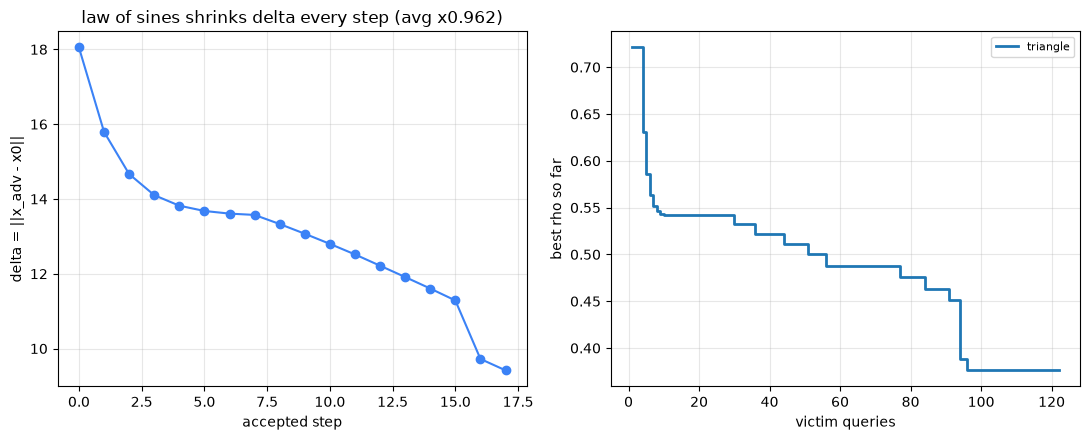

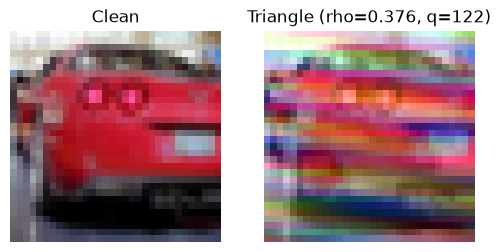

In [11]:
tctx = fresh(); loose = loose_start(tctx, x0, y0)
adv = attack_triangle(tctx, x0, y0, loose); qn = tctx.q
acc = accepted_points(tctx, x0, y0); deltas = np.linalg.norm(acc - x0, axis=1)
ratio = (deltas[-1] / deltas[0]) ** (1 / max(1, len(deltas) - 1))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(range(len(deltas)), deltas, "-o", color="#3b82f6")
ax[0].set_xlabel("accepted step"); ax[0].set_ylabel("delta = ||x_adv - x0||")
ax[0].set_title("law of sines shrinks delta every step (avg x%.3f)" % ratio); ax[0].grid(alpha=.3)
plot_convergence(tctx, x0, y0, ax[1], "triangle")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(adv, axes[1], "Triangle (rho=%.3f, q=%d)" % (rho(adv, x0), qn))
plt.show()

## 11. Biased Boundary (2019)  *(let a surrogate steer the walk)*

Everything since Section 7 was *pure* black-box. Now we add back a cheap helper: a surrogate gradient.
**Biased Boundary** blends the random orthogonal step of Boundary Attack with the surrogate's free
gradient direction, steering the same walk toward better directions.

**Graphic (from the real attacks):** the convergence curves of plain vs biased boundary on the identical
setup — the surrogate-steered walk drives $\rho$ far lower for the same query budget.

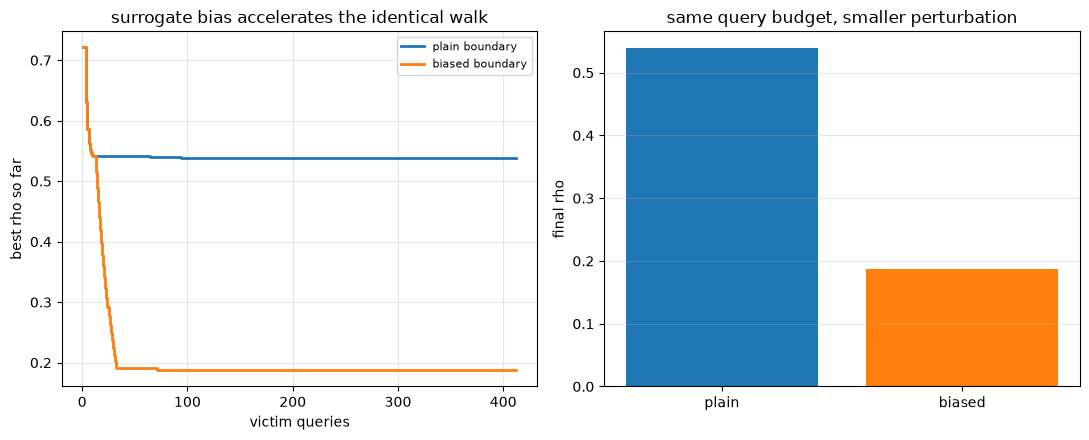

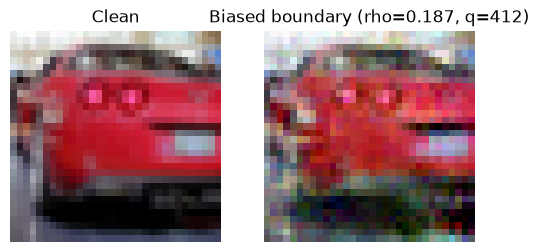

In [12]:
tp = fresh(); lp = loose_start(tp, x0, y0); xbp = attack_boundary(tp, x0, y0, lp, steps=400)
tb = fresh(); lb = loose_start(tb, x0, y0); adv = attack_boundary(tb, x0, y0, lb, bias=0.5, steps=400); qn = tb.q
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
plot_convergence(tp, x0, y0, ax[0], "plain boundary"); plot_convergence(tb, x0, y0, ax[0], "biased boundary")
ax[0].set_title("surrogate bias accelerates the identical walk")
ax[1].bar(["plain", "biased"], [rho(xbp, x0), rho(adv, x0)], color=["#1f77b4", "#ff7f0e"])
ax[1].set_ylabel("final rho"); ax[1].set_title("same query budget, smaller perturbation"); ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], "Clean"); show_cifar(adv, axes[1], "Biased boundary (rho=%.3f, q=%d)" % (rho(adv, x0), qn))
plt.show()

## 12. SQBA (2024)  *(fuse the surrogate gradient with HopSkipJump)*

The lineage's culmination. **SQBA** takes HopSkipJump's boundary-normal step but reads the normal **for
free** from the surrogate gradient. When the free direction stops helping, it *falls back* to HSJ's
query-based estimate — so it gracefully decays to HopSkipJump if the surrogate is useless.

**Graphic (from the real attack):** how many steps used the free surrogate direction vs the paid
fallback, and SQBA's convergence curve crushing pure HopSkipJump at the same query budget.

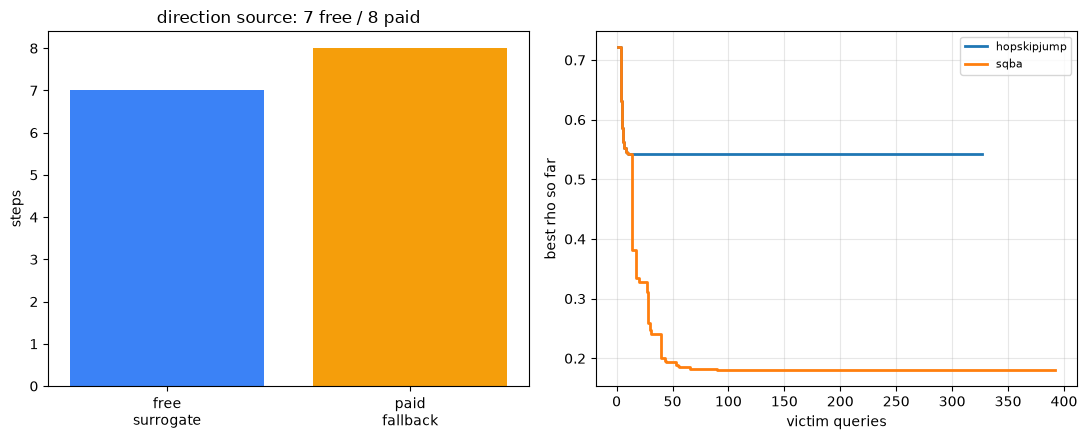

SQBA       rho=0.181  q=392  (7 free / 8 paid)
SQBA-full  rho=0.183  q=335  (12 free / 2 paid)


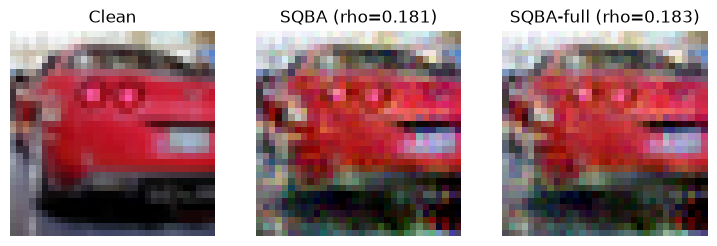

In [13]:
tctx = fresh(); loose = loose_start(tctx, x0, y0)
adv, wi, fb = attack_sqba(tctx, x0, y0, loose); qn = tctx.q
th = fresh(); lh = loose_start(th, x0, y0); attack_hsj(th, x0, y0, lh)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].bar(["free\nsurrogate", "paid\nfallback"], [wi, fb], color=["#3b82f6", "#f59e0b"])
ax[0].set_ylabel("steps"); ax[0].set_title("direction source: %d free / %d paid" % (wi, fb))
plot_convergence(th, x0, y0, ax[1], "hopskipjump"); plot_convergence(tctx, x0, y0, ax[1], "sqba")
plt.tight_layout(); plt.show()
tf = fresh(); adv_full, wif, fbf = attack_sqba_full(tf, x0, y0)
print("SQBA       rho=%.3f  q=%d  (%d free / %d paid)" % (rho(adv, x0), qn, wi, fb))
print("SQBA-full  rho=%.3f  q=%d  (%d free / %d paid)" % (rho(adv_full, x0), tf.q, wif, fbf))
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_cifar(x0, axes[0], "Clean")
show_cifar(adv, axes[1], "SQBA (rho=%.3f)" % rho(adv, x0))
show_cifar(adv_full, axes[2], "SQBA-full (rho=%.3f)" % rho(adv_full, x0)); plt.show()

## 13. Appendix: Surrogate-Quality Sweep

SQBA's grace under a bad surrogate, made concrete. We sweep from a strong helper down to a useless one
and watch the free/paid balance shift as it decays toward HopSkipJump (same logic as `cifar_lineage.py`).

In [14]:
print("Running Surrogate Sweep (Avg of 4 images)...")
sweep_imgs = [Xte[i].astype(np.float64) for i in range(len(Xte)) if victim_label(Xte[i]) == yte[i]][:4]

print(f"{'surrogate':<10}{'agree%':>8}{'rho':>8}{'victim_q':>10}{'white_only':>12}{'fallbacks':>11}")
for nm, cfg in [("strong ", dict(tag="surr_strong_air_auto")),
                ("weak   ", dict(frac=0.2, width=0.5, label_noise=0.2, epochs=2, seed=11, tag="surr_weak_air_auto")),
                ("useless", dict(frac=0.05, width=0.3, label_noise=0.5, epochs=1, seed=23, tag="surr_useless_air_auto"))]:
    s = surr if cfg.get("tag") == "surr_strong_air_auto" else build_surrogate(**cfg)
    agree = np.mean([victim_label(x) == make_label(s)(x) for x in Xte]) * 100
    c = make_ctx(s)
    rs, qs, wis, fbs = [], [], [], []
    for xi in sweep_imgs:
        yi = victim_label(xi)
        li = loose_start(c, xi, yi)
        c.q = 0; c.budget = float("inf")
        adv, wi, fb = attack_sqba(c, xi, yi, li)
        rs.append(rho(adv, xi)); qs.append(c.q); wis.append(wi); fbs.append(fb)
    print(f"{nm:<10}{agree:>7.1f}{np.mean(rs):>8.3f}{np.mean(qs):>10.0f}{np.mean(wis):>8.1f}/15{np.mean(fbs):>11.1f}")

Running Surrogate Sweep (Avg of 4 images)...
surrogate   agree%     rho  victim_q  white_only  fallbacks


strong       92.0   0.103       336     8.0/15        7.0


weak         80.5   0.227       484     3.2/15       11.8


useless      49.0   0.240       474     2.5/15       12.5


## 14. Appendix: Perceptual Guidance (Weighted $L_2$ + LPIPS)

A bonus: instead of flat $L_2$, run the *same* attacks in a transformed space $z = W \odot x$ so they hide
perturbation in textured regions. Because every attack runs through `Ctx`, this needs no change to
`attacks.py` — only a wrapped prediction/gradient and rescaled clip bounds.

In [15]:
import scipy.ndimage as ndimage
import lpips

# Dynamic LPIPS calculation: computes perceptual similarity using AlexNet features.
# Parameters:
# - x, y: Flattened image vectors (size 3072).
# Outputs:
# - dist: Float value representing the LPIPS perceptual distance.
_lpips_fn = None
def calculate_lpips(x, y):
    global _lpips_fn
    if _lpips_fn is None:
        try:
            _lpips_fn = lpips.LPIPS(net='alex')
        except Exception as e:
            return None
    # LPIPS expects input tensor values in range [-1.0, 1.0].
    # Multiplying by 2.0 and subtracting 1.0 rescales pixel values from [0.0, 1.0] to [-1.0, 1.0].
    tx = torch.tensor(x.reshape(1, 3, 32, 32)).float() * 2.0 - 1.0
    ty = torch.tensor(y.reshape(1, 3, 32, 32)).float() * 2.0 - 1.0
    with torch.no_grad():
        dist = _lpips_fn(tx, ty).item()
    return dist

# Local Sobel gradient-distance: calculates Euclidean distance between vertical/horizontal edges.
# Parameters:
# - x, y: Flattened image vectors (size 3072).
# Outputs:
# - dist: Float value representing the structural Sobel edge distance.
def calculate_sobel_dist(x, y):
    img_x = x.reshape(3, 32, 32)
    img_y = y.reshape(3, 32, 32)
    dist = 0.0
    for c in range(3):
        # ndimage.sobel computes vertical/horizontal derivatives using Sobel kernels.
        gx_x = ndimage.sobel(img_x[c], axis=0)
        gx_y = ndimage.sobel(img_x[c], axis=1)
        gy_x = ndimage.sobel(img_y[c], axis=0)
        gy_y = ndimage.sobel(img_y[c], axis=1)
        grad_x = np.sqrt(gx_x**2 + gx_y**2)
        grad_y = np.sqrt(gy_x**2 + gy_y**2)
        dist += np.linalg.norm(grad_x - grad_y)
    return dist

# Compute perceptual weight mask: computes local standard deviation of pixel values.
# Parameters:
# - x: Flattened image vector (size 3072).
# - epsilon: Float smoothing parameter (default 0.25) to avoid division by zero or collapse in flat regions.
# - filter_size: Window size (default 3) for computing local mean/variance.
# Outputs:
# - w: Flattened weight mask of shape (3072,).
# Hardcoded Choices:
# - filter_size=3: Chosen as a 3x3 local pixel window to compute local variance.
# - epsilon=0.25: Chosen because a smaller epsilon (e.g. 0.08) collapses the z-space, distorting gradients.
# - sigma=1.0: Gaussian smoothing kernel size. Smooths the weight boundaries to ensure gradients remain stable.
def compute_perceptual_weights(x, epsilon=0.25, filter_size=3):
    img = x.reshape(3, 32, 32)
    weights = []
    for c in range(3):
        # Compute local mean (uniform filter) and local mean of squares
        mean = ndimage.uniform_filter(img[c], size=filter_size, mode='reflect')
        mean_sq = ndimage.uniform_filter(img[c]**2, size=filter_size, mode='reflect')
        # Local variance = E[X^2] - (E[X])^2
        var = np.maximum(mean_sq - mean**2, 0.0)
        std = np.sqrt(var)
        # Flat areas (low std) get large weights (high penalty).
        # Textured areas (high std) get small weights (low penalty), guiding noise to hide there.
        w = 1.0 / (std + epsilon)
        w_smoothed = ndimage.gaussian_filter(w, sigma=1.0)
        weights.append(w_smoothed)
    weights = np.array(weights)
    weights /= np.mean(weights) # Normalize so the average weight is 1.0
    return weights.ravel()

# Space Transformation Wrapper: runs standard L2 attacks in coordinates z = w * x.
# In z-space, standard L2 distance is identical to weighted L2 distance in x-space:
# ||z - z0||_2 = ||w * (x - x0)||_2.
# Parameters:
# - attack_name: String name of the attack.
# - x0, y0: Clean image and label.
# - loose: Loose starting point vector.
# - w: The weight mask vector.
# Outputs:
# - x_adv: The resulting adversarial image in normal [0, 1] pixel space.
def run_attack_weighted(attack_name, x0, y0, loose, w):
    z0 = w * x0
    loose_z = loose * w
    
    def predict_z(z):
        return victim_label(np.clip(z / w, 0.0, 1.0))
        
    def sgrad_z(z, y0_curr):
        g_x = ctx.sgrad(np.clip(z / w, 0.0, 1.0), y0_curr)
        g_z = g_x / w
        n = np.linalg.norm(g_z)
        return g_z / n if n else g_z

    pool_X_z = Xtr * w
    ctx_z = Ctx(predict_z, sgrad_z, pool_X_z, ytr, rng=np.random.default_rng(0), lo=0.0, hi=w)
    ctx_z.budget = float("inf")
    
    if attack_name == "sign-opt":
        fn = lambda: attack_sign_opt(ctx_z, z0, y0, loose_z)
    elif attack_name == "triangle":
        fn = lambda: attack_triangle(ctx_z, z0, y0, loose_z)
    elif attack_name == "biased-bdry":
        fn = lambda: attack_boundary(ctx_z, z0, y0, loose_z, bias=0.5, steps=400)
    elif attack_name == "sqba":
        fn = lambda: attack_sqba(ctx_z, z0, y0, loose_z)[0]
    else:
        raise ValueError(f"Unknown attack: {attack_name}")
        
    z_adv = fn()
    return np.clip(z_adv / w, 0.0, 1.0)

# Run standard vs weighted comparison
w_mask = compute_perceptual_weights(x0, epsilon=0.25, filter_size=3)
test_attacks = ["sign-opt", "triangle", "biased-bdry", "sqba"]

print(f"{'attack':<13}{'metric':<10}{'standard L2':>15}{'weighted L2':>15}{'improvement%':>15}")
print("=" * 70)

for name in test_attacks:
    ctx.q = 0
    if name == "sign-opt":
        adv_std = attack_sign_opt(ctx, x0, y0, loose)
    elif name == "triangle":
        adv_std = attack_triangle(ctx, x0, y0, loose)
    elif name == "biased-bdry":
        adv_std = attack_boundary(ctx, x0, y0, loose, bias=0.5, steps=400)
    elif name == "sqba":
        adv_std = attack_sqba(ctx, x0, y0, loose)[0]
        
    adv_w = run_attack_weighted(name, x0, y0, loose, w_mask)
    
    l2_std = rho(adv_std, x0)
    l2_w = rho(adv_w, x0)
    lp_std = calculate_lpips(adv_std, x0)
    lp_w = calculate_lpips(adv_w, x0)
    sob_std = calculate_sobel_dist(adv_std, x0)
    sob_w = calculate_sobel_dist(adv_w, x0)
    
    print(f"{name:<13}{'rho (L2)':<10}{l2_std:>15.3f}{l2_w:>15.3f}{(l2_std - l2_w)/l2_std*100:>14.1f}%")
    if lp_std is not None and lp_w is not None:
        print(f"{'':<13}{'LPIPS':<10}{lp_std:>15.4f}{lp_w:>15.4f}{(lp_std - lp_w)/lp_std*100:>14.1f}%")
    print(f"{'':<13}{'Sobel':<10}{sob_std:>15.3f}{sob_w:>15.3f}{(sob_std - sob_w)/sob_std*100:>14.1f}%")
    print("-" * 70)

attack       metric        standard L2    weighted L2   improvement%


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/d3adman/.cache/uv/archive-v0/ne9A2Bukri1aZB_1X3itA/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/d3adman/.cache/uv/archive-v0/ne9A2Bukri1aZB_1X3itA/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/d3adman/.cache/uv/archive-v0/ne9A2Bukri1aZB_1X3itA/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
sign-opt     rho (L2)            0.406          0.410          -1.1%
             LPIPS              0.0281         0.0266           5.3%
             Sobel              31.346         30.042           4.2%
----------------------------------------------------------------------


triangle     rho (L2)            0.337          0.424         -25.7%
             LPIPS              0.0574         0.0346          39.7%
             Sobel              38.348         46.198         -20.5%
----------------------------------------------------------------------


biased-bdry  rho (L2)            0.184          0.185          -0.7%
             LPIPS              0.0106         0.0096           9.5%
             Sobel              28.729         30.223          -5.2%
----------------------------------------------------------------------


sqba         rho (L2)            0.181          0.185          -2.2%
             LPIPS              0.0093         0.0093           0.1%
             Sobel              31.493         32.187          -2.2%
----------------------------------------------------------------------


## 15. Appendix: Multi-Image Gallery

Finally, three representative rungs — white-box **PGD**, pure black-box **HopSkipJump**, and
surrogate-assisted **SQBA** — across several test images, to compare visual quality and query cost.

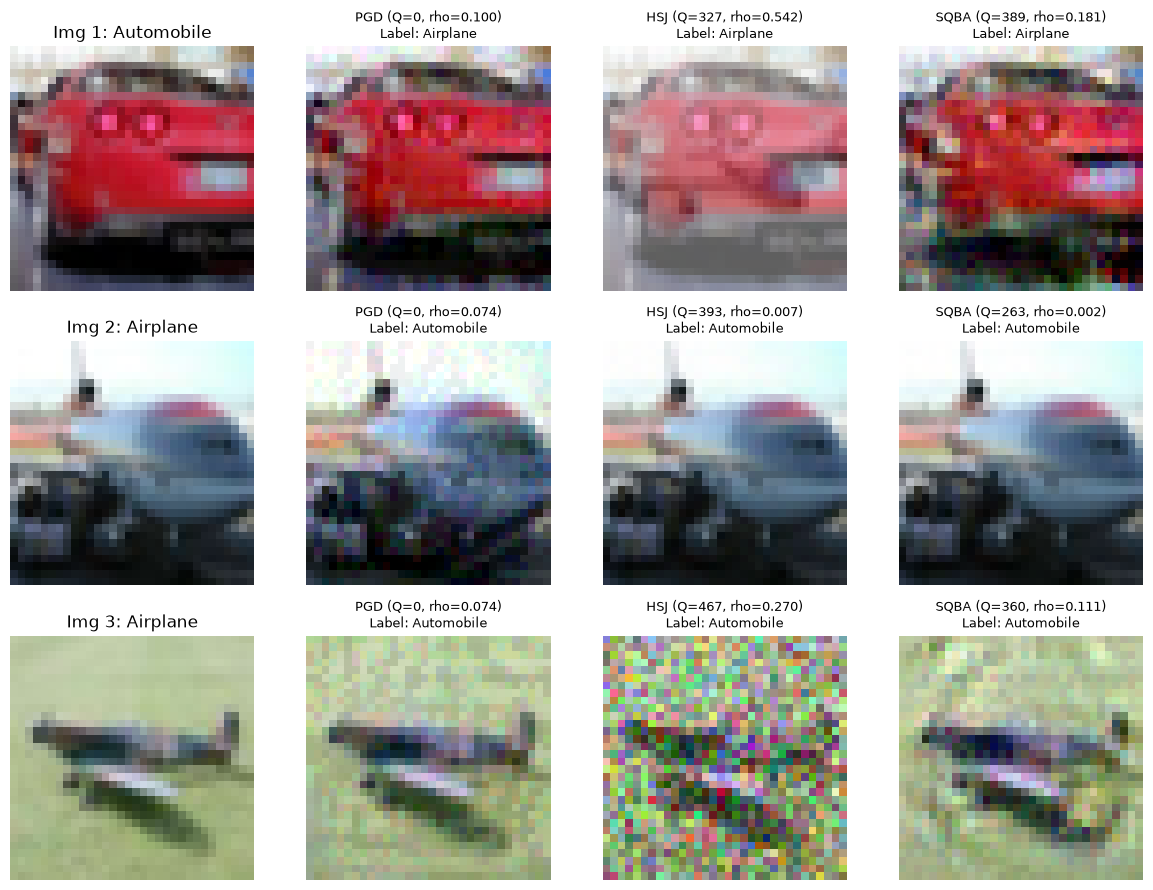

In [16]:
# Select 3 test images correctly classified by the victim model
gallery_imgs = []
gallery_labels = []
for i in range(len(Xte)):
    xi = Xte[i].astype(np.float64)
    yi = yte[i]
    if victim_label(xi) == yi:
        gallery_imgs.append(xi)
        gallery_labels.append(yi)
        if len(gallery_imgs) == 3:
            break

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for row_idx, (xi, yi) in enumerate(zip(gallery_imgs, gallery_labels)):
    # 1. Clean image
    show_cifar(xi, axes[row_idx, 0], f"Img {row_idx+1}: {'Airplane' if yi==0 else 'Automobile'}")
    
    # 2. PGD Attack (Replica Surrogate)
    ctx.q = 0
    adv_pgd = attack_pgd(xi, yi, wb_grad_fn)
    label_pgd = victim_label(adv_pgd)
    pgd_lbl = 'Airplane' if label_pgd==0 else 'Automobile'
    axes[row_idx, 1].imshow(np.clip(adv_pgd.reshape(3, 32, 32).transpose(1, 2, 0), 0.0, 1.0))
    axes[row_idx, 1].set_title(f"PGD (Q=0, rho={rho(adv_pgd, xi):.3f})\nLabel: {pgd_lbl}", fontsize=9)
    axes[row_idx, 1].axis('off')
    
    # 3. HopSkipJump Attack (Pure Black-Box)
    ctx.q = 0
    loose_i = loose_start(ctx, xi, yi)
    adv_hsj = attack_hsj(ctx, xi, yi, loose_i)
    label_hsj = victim_label(adv_hsj)
    hsj_lbl = 'Airplane' if label_hsj==0 else 'Automobile'
    axes[row_idx, 2].imshow(np.clip(adv_hsj.reshape(3, 32, 32).transpose(1, 2, 0), 0.0, 1.0))
    axes[row_idx, 2].set_title(f"HSJ (Q={ctx.q}, rho={rho(adv_hsj, xi):.3f})\nLabel: {hsj_lbl}", fontsize=9)
    axes[row_idx, 2].axis('off')
    
    # 4. SQBA Attack (Surrogate Guidance)
    ctx.q = 0
    adv_sqba = attack_sqba(ctx, xi, yi, loose_i)[0]
    label_sqba = victim_label(adv_sqba)
    sqba_lbl = 'Airplane' if label_sqba==0 else 'Automobile'
    axes[row_idx, 3].imshow(np.clip(adv_sqba.reshape(3, 32, 32).transpose(1, 2, 0), 0.0, 1.0))
    axes[row_idx, 3].set_title(f"SQBA (Q={ctx.q}, rho={rho(adv_sqba, xi):.3f})\nLabel: {sqba_lbl}", fontsize=9)
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.show()